# DJIA Smart Beta — Model Comparison

## Objective
Systematic comparison across **three model families** on the same pipeline (same panel, same target, same walk-forward, same allocator):

| Model | Type | Notes |
|---|---|---|
| **Ridge + Lasso (ensemble)** | Regularized linear | v5 approach — baseline |
| **XGBoost** | Gradient boosted trees | Captures nonlinearity + interactions |
| **Random Forest** | Bagged trees | Low variance, robust to noise |

For each model we run the **Top-K stability-weighted** variant (best variant identified in v5),
and then compare metric by metric across IS / OOS / FULL.

## Preview of the Expected Outcome
In monthly financial datasets with ~5000 observations and a noisy alpha signal:
- Nonlinear models (XGB, RF) tend to **overfit** the pre-2019 IS regime
- The regularized linear model (Ridge+Lasso) gives up a bit of IS in exchange for **cleaner OOS**
- The linear ensemble is typically **more parsimonious, more stable, and with more contained TE**

Let's see whether this intuition holds on the real data.


## 1. Setup

In [ ]:
import sys, subprocess, os, warnings
warnings.filterwarnings("ignore")

def _ensure(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.run([sys.executable,"-m","pip","install","-q",pkg], check=False)
_ensure("xgboost")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(12,5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
print("xgboost version:", xgb.__version__)


xgboost version: 3.2.0


In [ ]:
# ============================================================
# Global parameters (identical to v5 / xgboost.ipynb for fairness)
# ============================================================
HORIZON_MONTHS   = 1
START_TRAIN_DATE = pd.Timestamp("2010-12-31")
IS_END           = pd.Timestamp("2018-12-31")
OOS_START        = pd.Timestamp("2019-01-01")
LONG_ONLY = True
MAX_W = 0.15; MIN_W = 0.001
LAMBDA_TILT_GRID = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
RISK_AWARE_BETA  = 0.5
TOP_K_FEATURES   = 8

# Ridge / Lasso hyperparameters
ALPHAS_RIDGE = [0.01, 0.1, 1.0, 10.0, 100.0]
ALPHAS_LASSO = np.logspace(-5, -1, 15)

# XGBoost hyperparameters (conservative)
XGB_PARAMS = dict(
    n_estimators=200, learning_rate=0.03, max_depth=4,
    min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    objective="reg:squarederror", tree_method="hist",
    random_state=42, n_jobs=-1, verbosity=0,
)

# Random Forest hyperparameters (conservative)
RF_PARAMS = dict(
    n_estimators=300, max_depth=6,
    min_samples_leaf=20, max_features="sqrt",
    bootstrap=True, random_state=42, n_jobs=-1,
)

print(f"H={HORIZON_MONTHS}m, IS<={IS_END.date()}, OOS>={OOS_START.date()}, top_K={TOP_K_FEATURES}")


H=1m, IS<=2018-12-31, OOS>=2019-01-01, top_K=8


In [ ]:
# Data loading (same logic as v5)
candidates_panel = ["/content/djia_panel_finale_v2.csv","./djia_panel_finale_v2.csv",
                   "./cartella_finale/djia_panel_finale_v2.csv","../cartella_finale/djia_panel_finale_v2.csv"]
PANEL_PATH = next((p for p in candidates_panel if os.path.exists(p)), None)
INDEX_PATH = (PANEL_PATH or "").replace("djia_panel_finale_v2.csv","djia_index_series_v2.csv")
panel = pd.read_csv(PANEL_PATH, parse_dates=["Date"])
idx   = pd.read_csv(INDEX_PATH, parse_dates=["Date"]).sort_values("Date")
print(f"Loaded panel {panel.shape}, index {idx.shape}")


Loaded panel (6930, 34), index (231, 9)


## 2. Target and feature engineering (identical to v5)

In [ ]:
H = HORIZON_MONTHS
panel_full = panel.sort_values(["Ticker","Date"]).copy()

def fwd_h(group, h):
    r = group["Return_monthly"].values
    out = np.full(len(r), np.nan)
    for i in range(len(r)-h):
        cum = 1.0
        for k in range(1,h+1): cum *= (1+r[i+k])
        out[i] = cum - 1
    return pd.Series(out, index=group.index)

panel_full["fwd_ret_h"] = panel_full.groupby("Ticker", group_keys=False).apply(lambda g: fwd_h(g, H))
djitr_lvl = (1+idx.set_index("Date")["Return_DJITR"].sort_index().fillna(0)).cumprod()
panel_full["fwd_djitr_h"] = panel_full["Date"].map(djitr_lvl.shift(-H)/djitr_lvl - 1)
panel_full["y"] = panel_full["fwd_ret_h"] - panel_full["fwd_djitr_h"]

df = panel_full[panel_full["In_Index"]==1].copy()
df = df.dropna(subset=["y"]).reset_index(drop=True)
print(f"Target months: {df['Date'].nunique()}")


Target months: 230


In [ ]:
FEAT_TICKER = ["Return_monthly","Return_3m","Return_12m","Volatility_12m","Sharpe_12m","Alpha_vs_DJIA"]
FEAT_MACRO  = ["VIX_ZScore","HY_Spread","YieldCurve_10y2y","Recession","Stress_Score"]

# Imputation
for f in FEAT_TICKER:
    df[f] = df.groupby("Date")[f].transform(lambda s: s.fillna(s.median()))
df[FEAT_TICKER] = df[FEAT_TICKER].fillna(0)
for f in FEAT_MACRO:
    df[f] = df[f].fillna(method="ffill").fillna(method="bfill").fillna(0)

# Interactions
df["Sharpe_x_VIX"]   = df["Sharpe_12m"]     * df["VIX_ZScore"]
df["Mom12_x_Recess"] = df["Return_12m"]     * df["Recession"]
df["Vol_x_HY"]       = df["Volatility_12m"] * df["HY_Spread"]
df["Mom3_x_Curve"]   = df["Return_3m"]      * df["YieldCurve_10y2y"]
FEAT_INTER = ["Sharpe_x_VIX","Mom12_x_Recess","Vol_x_HY","Mom3_x_Curve"]

def rank_cs(df, cols):
    out=df.copy()
    for c in cols:
        ranks=out.groupby("Date")[c].rank(method="average")
        n=out.groupby("Date")[c].transform("count")
        out[c]=ranks/n - 0.5
    return out

def expanding_z(s):
    mu=s.expanding(min_periods=12).mean(); sd=s.expanding(min_periods=12).std().replace(0,1)
    return ((s-mu)/sd).fillna(0)

def cs_z(df, cols):
    out=df.copy(); g=out.groupby("Date")
    for c in cols:
        out[c]=(out[c]-g[c].transform("mean"))/g[c].transform("std").replace(0,1)
    out[cols]=out[cols].fillna(0); return out

df = rank_cs(df, FEAT_TICKER)
macro_ts = df.drop_duplicates("Date")[["Date"]+FEAT_MACRO].set_index("Date").sort_index()
for f in FEAT_MACRO:
    macro_ts[f] = expanding_z(macro_ts[f])
df = df.drop(columns=FEAT_MACRO).merge(macro_ts.reset_index(), on="Date")
df = cs_z(df, FEAT_INTER)

FEATURES = FEAT_TICKER + FEAT_MACRO + FEAT_INTER
print(f"Total features: {len(FEATURES)}")


Total features: 15


## 3. IS Stability Score — Computed with Ridge

For consistency the stability score (for the top-K variant) is computed with **Ridge** on the IS data.
The same top-K feature set is then used by all models, so that the comparison is on the **model**, not on the feature set.


In [ ]:
# IS walk-forward using Ridge only for the stability score
all_dates = sorted(df["Date"].unique())
is_forecast_dates = [d for d in all_dates if (d > START_TRAIN_DATE) and (d <= IS_END)]
if H > 1: is_forecast_dates = is_forecast_dates[::H]
print(f"IS forecast dates: {len(is_forecast_dates)}")

ridge_coefs = []
for t in is_forecast_dates:
    Xt = df.loc[df["Date"]<t, FEATURES].values
    yt = df.loc[df["Date"]<t, "y"].values
    if len(Xt) < 200: continue
    m_r = RidgeCV(alphas=ALPHAS_RIDGE, cv=5).fit(Xt, yt)
    ridge_coefs.append(pd.Series(m_r.coef_, index=FEATURES))
coef_r_df = pd.DataFrame(ridge_coefs)

abs_mean = coef_r_df.abs().mean()
sign_cons = (np.sign(coef_r_df) == np.sign(coef_r_df.mean())).mean()
stab = pd.DataFrame({"abs_mean": abs_mean, "sign_cons": sign_cons,
                     "stability": abs_mean * sign_cons})
stab["weight_norm"] = stab["stability"] / stab["stability"].max()
stab = stab.sort_values("stability", ascending=False)
print("\n=== STABILITY SCORE (Ridge) ===")
print(stab.round(5))

TOP_K_FEATS = stab.head(TOP_K_FEATURES).index.tolist()
print(f"\n>>> Top-{TOP_K_FEATURES} features:", TOP_K_FEATS)


IS forecast dates: 96

=== STABILITY SCORE (Ridge) ===
                  abs_mean  sign_cons  stability  weight_norm
Mom3_x_Curve       0.00446    1.00000    0.00446      1.00000
Return_12m         0.00337    1.00000    0.00337      0.75599
Return_monthly     0.00244    1.00000    0.00244      0.54694
Alpha_vs_DJIA      0.00226    1.00000    0.00226      0.50737
Recession          0.00201    1.00000    0.00201      0.45017
VIX_ZScore         0.00199    1.00000    0.00199      0.44644
Volatility_12m     0.00186    1.00000    0.00186      0.41730
Sharpe_12m         0.00166    0.97917    0.00162      0.36374
Return_3m          0.00122    1.00000    0.00122      0.27284
HY_Spread          0.00117    1.00000    0.00117      0.26128
Stress_Score       0.00086    1.00000    0.00086      0.19349
Mom12_x_Recess     0.00094    0.80208    0.00076      0.16952
YieldCurve_10y2y   0.00078    0.75000    0.00059      0.13134
Vol_x_HY           0.00079    0.70833    0.00056      0.12511
Sharpe_x_VIX   

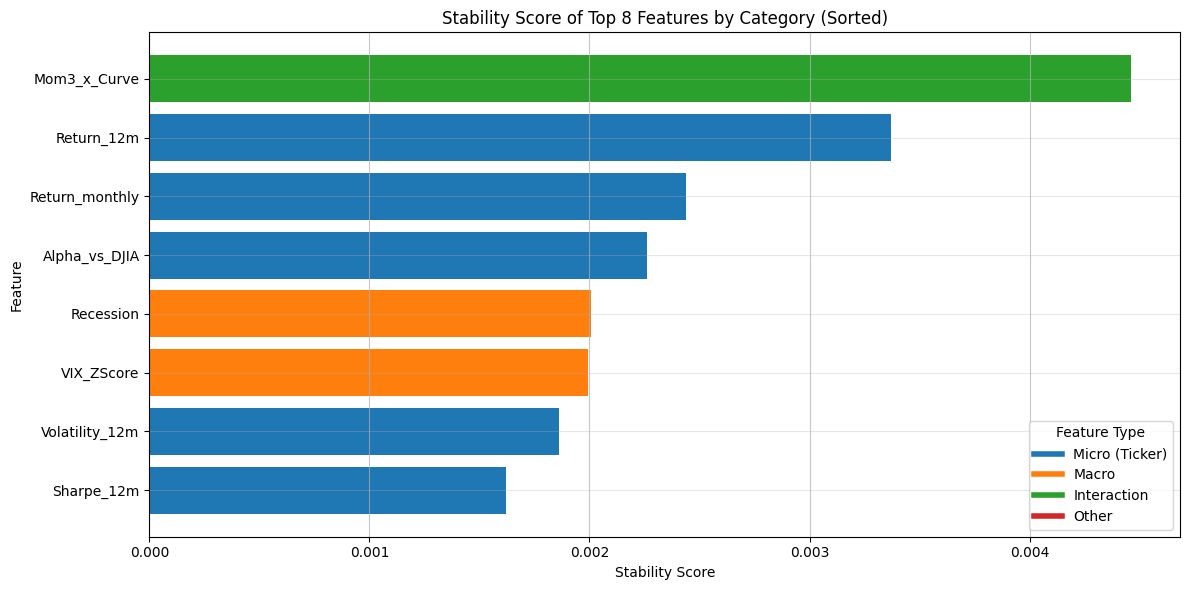

In [ ]:
import matplotlib.pyplot as plt

# Define feature categories
feature_categories = {}
for f in TOP_K_FEATS:
    if f in FEAT_TICKER:
        feature_categories[f] = "Micro (Ticker)"
    elif f in FEAT_MACRO:
        feature_categories[f] = "Macro"
    elif f in FEAT_INTER:
        feature_categories[f] = "Interaction"
    else:
        feature_categories[f] = "Other"

# Filter stab for top K features and add category
top_k_stab = stab.loc[TOP_K_FEATS].copy()
top_k_stab["Category"] = top_k_stab.index.map(feature_categories)

# Define colors for each category
category_colors = {
    "Micro (Ticker)": "tab:blue",
    "Macro": "tab:orange",
    "Interaction": "tab:green",
    "Other": "tab:red" # Fallback color
}

# Create the plot
plt.figure(figsize=(12, 6))

# Sort by stability in ascending order for horizontal bar chart to appear from bottom to top (most important at top)
top_k_stab_sorted = top_k_stab.sort_values(by='stability', ascending=True)

# Get colors for each feature based on its category
colors = [category_colors[cat] for cat in top_k_stab_sorted['Category']]

# Create the horizontal bar plot
plt.barh(top_k_stab_sorted.index, top_k_stab_sorted['stability'], color=colors)

plt.title("Stability Score of Top 8 Features by Category (Sorted)")
plt.ylabel("Feature")
plt.xlabel("Stability Score")
plt.yticks(rotation=0) # No rotation needed for y-axis labels

# Create a custom legend manually as plt.barh doesn't automatically create one for color-coded bars
legend_patches = [plt.Line2D([0], [0], color=v, lw=4, label=k) for k,v in category_colors.items()]
plt.legend(handles=legend_patches, title="Feature Type")

plt.grid(axis='x', alpha=0.7) # Grid on x-axis for horizontal bars
plt.tight_layout()
plt.show()

## 4. Walk-Forward — One per Model

All three models use the **same variant "Top-K"** (best identified in v5)
on the same feature subset, trained with the same monthly walk-forward procedure.


In [ ]:
def wf_walk_forward(df, features, model_factory, label):
    """Generic walk-forward: model_factory() -> new regressor at each t."""
    forecast_dates = [d for d in sorted(df["Date"].unique()) if d > START_TRAIN_DATE]
    if H > 1: forecast_dates = forecast_dates[::H]

    preds = []
    for t in forecast_dates:
        train_mask = df["Date"] < t
        pred_mask  = df["Date"] == t
        Xt = df.loc[train_mask, features].values
        yt = df.loc[train_mask, "y"].values
        Xp = df.loc[pred_mask,  features].values
        tk = df.loc[pred_mask, "Ticker"].values
        if len(Xt) < 200 or len(Xp)==0: continue
        m = model_factory()
        m.fit(Xt, yt)
        score = m.predict(Xp)
        for ticker, sc in zip(tk, score):
            preds.append({"Date": t, "Ticker": ticker, "score": float(sc)})
    pred_df = pd.DataFrame(preds)
    print(f"  [{label}] predictions: {len(pred_df)}")
    return pred_df

# --- Factories ---
def factory_ridge_lasso():
    """50/50 Ridge+Lasso ensemble (as in v5)."""
    class Ensemble:
        def fit(self, X, y):
            self.r = RidgeCV(alphas=ALPHAS_RIDGE, cv=5).fit(X, y)
            self.l = LassoCV(alphas=ALPHAS_LASSO, cv=5, max_iter=5000).fit(X, y)
            return self
        def predict(self, X):
            return 0.5 * self.r.predict(X) + 0.5 * self.l.predict(X)
    return Ensemble()

def factory_xgb():
    return xgb.XGBRegressor(**XGB_PARAMS)

def factory_rf():
    return RandomForestRegressor(**RF_PARAMS)

print("Running walk-forward for the 3 models (Top-K features)...")
pred_ridge = wf_walk_forward(df, TOP_K_FEATS, factory_ridge_lasso, "Ridge+Lasso")
pred_xgb   = wf_walk_forward(df, TOP_K_FEATS, factory_xgb,         "XGBoost")
pred_rf    = wf_walk_forward(df, TOP_K_FEATS, factory_rf,          "Random Forest")


Running walk-forward for the 3 models (Top-K features)...
  [Ridge+Lasso] predictions: 5445
  [XGBoost] predictions: 5445
  [Random Forest] predictions: 5445


## 5. Risk-Aware Tilt Allocator (Identical to v5)

In [ ]:
def smart_alloc(group, lam=1.5, beta_risk=0.5, max_w=0.15, min_w=0.001):
    g = group.copy().sort_values("Ticker").reset_index(drop=True); n=len(g)
    score_rank = (g["score"].rank() / n) - 0.5
    w_pw = g["Weight_PW"].values
    inv_vol = 1.0 / g["Volatility_12m_raw"].values
    inv_vol = inv_vol / inv_vol.sum()
    w_base = (1-beta_risk)*w_pw + beta_risk*inv_vol
    w_raw = w_base * np.exp(lam * score_rank.values)
    w_clip = np.clip(w_raw, min_w, max_w)
    w = w_clip / w_clip.sum()
    for _ in range(10):
        if w.max() <= max_w + 1e-6: break
        excess_mask = w > max_w
        excess = (w[excess_mask] - max_w).sum()
        w[excess_mask] = max_w
        non_e = ~excess_mask
        w[non_e] += excess * w[non_e] / w[non_e].sum()
    g["weight"] = w
    return g

df_vol_raw = panel[panel["In_Index"]==1][["Date","Ticker","Volatility_12m"]].rename(
    columns={"Volatility_12m":"Volatility_12m_raw"})
weight_pw_map = panel[panel["In_Index"]==1][["Date","Ticker","Weight_PW"]]


## 6. Tuning λ on IS, OOS Evaluation — One Block per Model

In [ ]:
def metrics(r, b):
    if len(r) == 0: return pd.Series(dtype=float)
    n_y = len(r) / (12/H)
    cagr  = (1+r).prod()**(1/n_y) - 1
    cagr_b= (1+b).prod()**(1/n_y) - 1
    vol = r.std() * np.sqrt(12/H); vol_b = b.std() * np.sqrt(12/H)
    sh = cagr/vol if vol>0 else np.nan
    sh_b = cagr_b/vol_b if vol_b>0 else np.nan
    te = (r-b).std() * np.sqrt(12/H); ir=(cagr-cagr_b)/te if te>0 else np.nan
    eq=(1+r).cumprod(); eq_b=(1+b).cumprod()
    mdd=(eq/eq.cummax()-1).min(); mdd_b=(eq_b/eq_b.cummax()-1).min()
    hit=((r-b)>0).mean()
    return pd.Series({"CAGR":cagr,"CAGR_B":cagr_b,"Vol":vol,"Vol_B":vol_b,
                      "Sharpe":sh,"Sharpe_B":sh_b,"TE":te,"IR":ir,
                      "MDD":mdd,"MDD_B":mdd_b,"Hit":hit,"N":len(r)})

def build_bt(pred_df_in):
    bt = pred_df_in.merge(df[["Date","Ticker","fwd_ret_h"]], on=["Date","Ticker"], how="left")
    bt = bt.merge(weight_pw_map, on=["Date","Ticker"], how="left")
    bt = bt.merge(df_vol_raw, on=["Date","Ticker"], how="left")
    bt["Volatility_12m_raw"] = bt["Volatility_12m_raw"].fillna(bt["Volatility_12m_raw"].median())
    fwd_djitr_map = df.drop_duplicates("Date").set_index("Date")["fwd_djitr_h"]
    bt["fwd_djitr_h"] = bt["Date"].map(fwd_djitr_map)
    return bt

def run_strategy(bt, lam, beta_risk):
    picks = bt.groupby("Date", group_keys=False).apply(
        lambda g: smart_alloc(g, lam=lam, beta_risk=beta_risk, max_w=MAX_W, min_w=MIN_W))
    strat = (picks.assign(c=picks["weight"]*picks["fwd_ret_h"]).groupby("Date")["c"].sum())
    bench = picks.drop_duplicates("Date").set_index("Date")["fwd_djitr_h"]
    res = pd.concat([strat.rename("Strategy"), bench.rename("DJITR")], axis=1).dropna()
    return res

def tune_and_evaluate(pred_df_in, label):
    bt = build_bt(pred_df_in)
    is_results = []
    for lam in LAMBDA_TILT_GRID:
        res = run_strategy(bt, lam, RISK_AWARE_BETA)
        is_part = res.loc[res.index <= IS_END]
        m = metrics(is_part["Strategy"], is_part["DJITR"])
        is_results.append({"lam": lam, "IR": m["IR"], "Sharpe": m["Sharpe"]})
    is_t = pd.DataFrame(is_results)
    best_lam = is_t.loc[is_t["IR"].idxmax(), "lam"]

    res_final = run_strategy(bt, best_lam, RISK_AWARE_BETA)
    is_p  = res_final.loc[res_final.index <= IS_END]
    oos_p = res_final.loc[res_final.index >= OOS_START]
    m_is  = metrics(is_p["Strategy"],  is_p["DJITR"])
    m_oos = metrics(oos_p["Strategy"], oos_p["DJITR"])
    m_full= metrics(res_final["Strategy"], res_final["DJITR"])
    print(f"\n--- {label}  (best_lam={best_lam}) ---")
    print(f"IS : IR={m_is['IR']:+.3f}  Sharpe={m_is['Sharpe']:.3f}  TE={m_is['TE']*100:.2f}%")
    print(f"OOS: IR={m_oos['IR']:+.3f}  Sharpe={m_oos['Sharpe']:.3f}  TE={m_oos['TE']*100:.2f}%  Hit={m_oos['Hit']:.3f}")
    return res_final, m_is, m_oos, m_full, best_lam

print("Tuning + evaluation for the 3 models...")
res_ridge, mi_r, mo_r, mf_r, lam_r = tune_and_evaluate(pred_ridge, "RIDGE+LASSO ENSEMBLE")
res_xgb,   mi_x, mo_x, mf_x, lam_x = tune_and_evaluate(pred_xgb,   "XGBOOST")
res_rf,    mi_f, mo_f, mf_f, lam_f = tune_and_evaluate(pred_rf,    "RANDOM FOREST")


Tuning + evaluation for the 3 models...

--- RIDGE+LASSO ENSEMBLE  (best_lam=2.5) ---
IS : IR=+0.655  Sharpe=1.352  TE=2.94%
OOS: IR=+0.210  Sharpe=0.701  TE=3.82%  Hit=0.535

--- XGBOOST  (best_lam=0.5) ---
IS : IR=+0.192  Sharpe=1.141  TE=1.44%
OOS: IR=-0.192  Sharpe=0.676  TE=1.53%  Hit=0.407

--- RANDOM FOREST  (best_lam=0.5) ---
IS : IR=+0.098  Sharpe=1.133  TE=1.42%
OOS: IR=+0.017  Sharpe=0.702  TE=1.64%  Hit=0.442


## 7. Unified Comparison Table

In [ ]:
def to_row(name, mi, mo, mf, lam):
    return {
        "model": name, "best_lam": lam,
        "IS_IR": mi["IR"], "IS_Sharpe": mi["Sharpe"], "IS_TE": mi["TE"],
        "OOS_IR": mo["IR"], "OOS_Sharpe": mo["Sharpe"], "OOS_CAGR": mo["CAGR"],
        "OOS_TE": mo["TE"], "OOS_Hit": mo["Hit"], "OOS_MDD": mo["MDD"],
        "FULL_IR": mf["IR"], "FULL_Sharpe": mf["Sharpe"], "FULL_CAGR": mf["CAGR"],
        "FULL_TE": mf["TE"],
    }

compare = pd.DataFrame([
    to_row("Ridge+Lasso",  mi_r, mo_r, mf_r, lam_r),
    to_row("XGBoost",      mi_x, mo_x, mf_x, lam_x),
    to_row("Random Forest",mi_f, mo_f, mf_f, lam_f),
]).set_index("model")

print("="*78)
print("MODEL COMPARISON — same panel, same top-K features, same allocator")
print("="*78)
cols_view = ["best_lam","IS_IR","IS_Sharpe","OOS_IR","OOS_Sharpe","OOS_TE","OOS_Hit","FULL_IR"]
print(compare[cols_view].round(4))

# IS vs OOS gap = overfitting symptom
compare["overfit_gap"] = compare["IS_IR"] - compare["OOS_IR"]
print("\n--- Overfit gap (IS_IR - OOS_IR; lower = more robust) ---")
print(compare[["IS_IR","OOS_IR","overfit_gap"]].round(4))

best_oos  = compare["OOS_IR"].idxmax()
best_full = compare["FULL_IR"].idxmax()
lowest_of = compare["overfit_gap"].idxmin()
print(f"\n>>> Best OOS_IR : {best_oos}")
print(f">>> Best FULL_IR: {best_full}")
print(f">>> Min overfit gap: {lowest_of}")


MODEL COMPARISON — same panel, same top-K features, same allocator
               best_lam   IS_IR  IS_Sharpe  OOS_IR  OOS_Sharpe  OOS_TE  \
model                                                                    
Ridge+Lasso         2.5  0.6554     1.3523  0.2103      0.7014  0.0382   
XGBoost             0.5  0.1924     1.1407 -0.1916      0.6759  0.0153   
Random Forest       0.5  0.0984     1.1329  0.0173      0.7020  0.0164   

               OOS_Hit  FULL_IR  
model                            
Ridge+Lasso     0.5349   0.4123  
XGBoost         0.4070   0.0034  
Random Forest   0.4419   0.0568  

--- Overfit gap (IS_IR - OOS_IR; lower = more robust) ---
                IS_IR  OOS_IR  overfit_gap
model                                     
Ridge+Lasso    0.6554  0.2103       0.4450
XGBoost        0.1924 -0.1916       0.3839
Random Forest  0.0984  0.0173       0.0811

>>> Best OOS_IR : Ridge+Lasso
>>> Best FULL_IR: Ridge+Lasso
>>> Min overfit gap: Random Forest


## 8. Comparison Plots — Equity Curves and Cumulative Excess

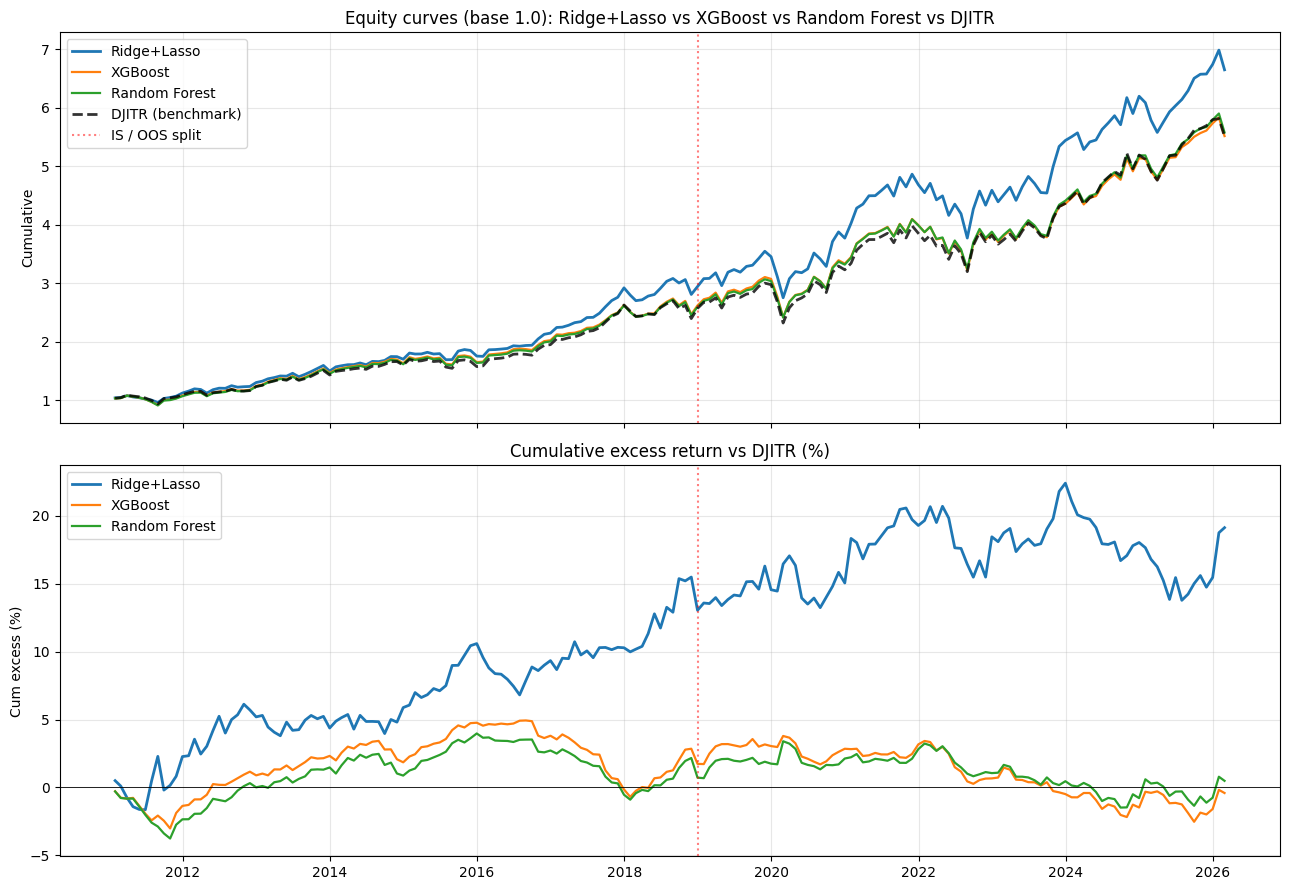

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

styles = {
    "Ridge+Lasso":   {"color": "tab:blue",   "lw": 2.0, "ls": "-"},
    "XGBoost":       {"color": "tab:orange", "lw": 1.6, "ls": "-"},
    "Random Forest": {"color": "tab:green",  "lw": 1.6, "ls": "-"},
}
results_dict = {"Ridge+Lasso": res_ridge, "XGBoost": res_xgb, "Random Forest": res_rf}

for label, res in results_dict.items():
    eq = (1+res["Strategy"]).cumprod()
    axs[0].plot(res.index, eq, label=label, **styles[label])

eq_b = (1+res_ridge["DJITR"]).cumprod()
axs[0].plot(res_ridge.index, eq_b, label="DJITR (benchmark)", lw=2,
            color="black", alpha=0.8, ls="--")
axs[0].axvline(IS_END, color="red", ls=":", alpha=0.5, label="IS / OOS split")
axs[0].set_title("Equity curves (base 1.0): Ridge+Lasso vs XGBoost vs Random Forest vs DJITR")
axs[0].legend(loc="upper left"); axs[0].set_ylabel("Cumulative")

for label, res in results_dict.items():
    cum_excess = (res["Strategy"] - res["DJITR"]).cumsum() * 100
    axs[1].plot(res.index, cum_excess, label=label, **styles[label])

axs[1].axhline(0, color="black", lw=0.6)
axs[1].axvline(IS_END, color="red", ls=":", alpha=0.5)
axs[1].set_title("Cumulative excess return vs DJITR (%)")
axs[1].legend(loc="upper left"); axs[1].set_ylabel("Cum excess (%)")
plt.tight_layout()
plt.savefig("model_comparison_equity.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# CAGR for Ridge+Lasso in the OOS period
print(f"Compound annual CAGR for Ridge+Lasso in the OOS period: {compare.loc['Ridge+Lasso', 'OOS_CAGR']:.4f}")

# CAGR for XGBoost in the OOS period
print(f"Compound annual CAGR for XGBoost in the OOS period: {compare.loc['XGBoost', 'OOS_CAGR']:.4f}")

# CAGR for Random Forest in the OOS period
print(f"Compound annual CAGR for Random Forest in the OOS period: {compare.loc['Random Forest', 'OOS_CAGR']:.4f}")

Compound annual CAGR for Ridge+Lasso in the OOS period: 0.1205
Compound annual CAGR for XGBoost in the OOS period: 0.1095
Compound annual CAGR for Random Forest in the OOS period: 0.1127


In [ ]:
print(f"Maximum Drawdown (OOS) for Ridge+Lasso: {compare.loc['Ridge+Lasso', 'OOS_MDD']:.4f}")
print(f"Maximum Drawdown (OOS) for XGBoost: {compare.loc['XGBoost', 'OOS_MDD']:.4f}")
print(f"Maximum Drawdown (OOS) for Random Forest: {compare.loc['Random Forest', 'OOS_MDD']:.4f}")

Maximum Drawdown (OOS) for Ridge+Lasso: -0.2245
Maximum Drawdown (OOS) for XGBoost: -0.2216
Maximum Drawdown (OOS) for Random Forest: -0.2137


In [ ]:
import pandas as pd

# Extract OOS metrics for models
model_cagr = compare['OOS_CAGR']
model_mdd = compare['OOS_MDD']
model_sharpe = compare['OOS_Sharpe']

# Extract OOS benchmark metrics (they are the same across mo_r, mo_x, mo_f)
benchmark_cagr_oos = mo_r['CAGR_B']
benchmark_mdd_oos = mo_r['MDD_B']
benchmark_sharpe_oos = mo_r['Sharpe_B']
n_months_oos = mo_r['N'] # Number of months in OOS period (86)
n_years_oos = n_months_oos / (12 / HORIZON_MONTHS)

# Calculate Total Return for models
total_return_ridge = (1 + model_cagr['Ridge+Lasso'])**n_years_oos - 1
total_return_xgb = (1 + model_cagr['XGBoost'])**n_years_oos - 1
total_return_rf = (1 + model_cagr['Random Forest'])**n_years_oos - 1

# Calculate Total Return for benchmark
total_return_benchmark = (1 + benchmark_cagr_oos)**n_years_oos - 1

# Create a dictionary to hold the data
data = {
    'CAGR': {
        'Ridge+Lasso': model_cagr['Ridge+Lasso'],
        'XGBoost': model_cagr['XGBoost'],
        'Random Forest': model_cagr['Random Forest'],
        'Benchmark DJITR': benchmark_cagr_oos
    },
    'Sharpe': {
        'Ridge+Lasso': model_sharpe['Ridge+Lasso'],
        'XGBoost': model_sharpe['XGBoost'],
        'Random Forest': model_sharpe['Random Forest'],
        'Benchmark DJITR': benchmark_sharpe_oos
    },
    'MaxDD': {
        'Ridge+Lasso': model_mdd['Ridge+Lasso'],
        'XGBoost': model_mdd['XGBoost'],
        'Random Forest': model_mdd['Random Forest'],
        'Benchmark DJITR': benchmark_mdd_oos
    },
    'Total Return': {
        'Ridge+Lasso': total_return_ridge,
        'XGBoost': total_return_xgb,
        'Random Forest': total_return_rf,
        'Benchmark DJITR': total_return_benchmark
    }
}

# Create the DataFrame
summary_df = pd.DataFrame(data)

print("\n--- OOS Performance Summary ---")
print(summary_df.round(4))



--- OOS Performance Summary ---
                   CAGR  Sharpe   MaxDD  Total Return
Ridge+Lasso      0.1205  0.7014 -0.2245        1.2597
XGBoost          0.1095  0.6759 -0.2216        1.1059
Random Forest    0.1127  0.7020 -0.2137        1.1500
Benchmark DJITR  0.1124  0.6853 -0.2273        1.1461
